In [2]:
import pandas as pd

In [7]:
datos_modelo = pd.read_parquet(
    "dataset_supervisado.parquet"
)

In [8]:
train = datos_modelo[
    datos_modelo["anio"] <= 2022
].copy()

validation = datos_modelo[
    datos_modelo["anio"].between(2023, 2024)
].copy()

test = datos_modelo[
    datos_modelo["anio"] == 2025
].copy()

#En esta parte realizamos la división del dataset. 
#Se tomaron los datos de 2018-2022 para los datos de entrenamiento. 
#Luego los de 2023-2024 para los de validación.
#Y por ultimo los de 2025 para la prueba.

In [9]:
print("TRAIN:", train.shape)
print("VALIDATION:", validation.shape)
print("TEST:", test.shape)

#Tamaños de cada separación.

TRAIN: (4959, 51)
VALIDATION: (1995, 51)
TEST: (969, 51)


In [10]:
for nombre, df_particion in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test)
]:
    print(
        nombre,
        df_particion["fecha_inicio_semana"].min(),
        df_particion["fecha_inicio_semana"].max()
    )

Train 2018-01-01 00:00:00 2022-12-26 00:00:00
Validation 2023-01-02 00:00:00 2024-12-30 00:00:00
Test 2025-01-06 00:00:00 2025-12-22 00:00:00


In [11]:
for nombre, df_particion in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test)
]:
    print(f"\n{nombre}")

    print(
        (
            df_particion["nivel_actividad_firms"]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    )

#Porcentaje de cada clase en cada separación.


Train
nivel_actividad_firms
Sin detección    60.52
Bajo             15.89
Moderado         13.73
Alto              9.86
Name: proportion, dtype: float64

Validation
nivel_actividad_firms
Sin detección    67.82
Bajo             14.94
Moderado         11.88
Alto              5.36
Name: proportion, dtype: float64

Test
nivel_actividad_firms
Sin detección    63.26
Bajo             15.58
Moderado         11.97
Alto              9.18
Name: proportion, dtype: float64


In [12]:
target = "nivel_actividad_firms"

In [13]:
features = [
    # Semana anterior
    "precipitation_sum_weekly_lag1",
    "temperature_2m_max_mean_weekly_lag1",
    "temperature_2m_min_mean_weekly_lag1",
    "relative_humidity_2m_min_mean_weekly_lag1",
    "wind_speed_10m_max_mean_weekly_lag1",
    "et0_fao_evapotranspiration_sum_weekly_lag1",

    # 2 semanas anteriores
    "precipitation_sum_weekly_prev_2w_sum",
    "temperature_2m_max_mean_weekly_prev_2w_mean",
    "temperature_2m_min_mean_weekly_prev_2w_mean",
    "relative_humidity_2m_min_mean_weekly_prev_2w_mean",
    "wind_speed_10m_max_mean_weekly_prev_2w_mean",
    "et0_fao_evapotranspiration_sum_weekly_prev_2w_sum",

    # 4 semanas anteriores
    "precipitation_sum_weekly_prev_4w_sum",
    "temperature_2m_max_mean_weekly_prev_4w_mean",
    "temperature_2m_min_mean_weekly_prev_4w_mean",
    "relative_humidity_2m_min_mean_weekly_prev_4w_mean",
    "wind_speed_10m_max_mean_weekly_prev_4w_mean",
    "et0_fao_evapotranspiration_sum_weekly_prev_4w_sum"
]

In [14]:
X_train = train[features]
y_train = train["nivel_actividad_firms"]

X_val = validation[features]
y_val = validation["nivel_actividad_firms"]

X_test = test[features]
y_test = test["nivel_actividad_firms"]


In [15]:
print("Nulos X_train:", X_train.isnull().sum().sum())
print("Nulos X_val:", X_val.isnull().sum().sum())
print("Nulos X_test:", X_test.isnull().sum().sum())

Nulos X_train: 0
Nulos X_val: 0
Nulos X_test: 0


In [16]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(4959, 18) (4959,)
(1995, 18) (1995,)
(969, 18) (969,)


In [ ]:
MODELO BASE: RANDOM FOREST

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [22]:
datos = pd.read_parquet(
    "dataset_supervisado.parquet"
)

datos.shape

(7923, 51)

In [23]:
modelo_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [24]:
#Entrenamiento del modelo
modelo_base.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [25]:
#Validación del modelo
y_pred_val = modelo_base.predict(X_val)

In [26]:
accuracy = accuracy_score(y_val, y_pred_val)

balanced_accuracy = balanced_accuracy_score(
    y_val,
    y_pred_val
)

f1_macro = f1_score(
    y_val,
    y_pred_val,
    average="macro"
)

print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("F1 Macro:", round(f1_macro, 4))

Accuracy: 0.6596
Balanced Accuracy: 0.2602
F1 Macro: 0.2269


In [ ]:
#esta diferencia en las metricas sugiere que el modelo está funcionando mucho mejor para alguna clase que para 
#las demás, probablemente porque hay un desbalance importante entre las categorías de nivel_actividad_firms.

In [30]:
print(
    classification_report(
        y_val,
        y_pred_val,
        labels=[
            "Sin detección",
            "Bajo",
            "Moderado",
            "Alto"
        ]
    )
)

               precision    recall  f1-score   support

Sin detección       0.68      0.97      0.80      1353
         Bajo       0.15      0.01      0.02       298
     Moderado       0.00      0.00      0.00       237
         Alto       0.14      0.07      0.09       107

     accuracy                           0.66      1995
    macro avg       0.24      0.26      0.23      1995
 weighted avg       0.49      0.66      0.55      1995



In [ ]:
#aca observamos los resultados por clases IMPORTANTE PARA EL INFORME!!!!
#el accuracy a 66% es solamente que casi siempre esta prediciendo la clase de sin deteccion
#en moderado hay 237 casos pero el modelo no identificó ninguno

#El modelo base presentó un accuracy de 65,96 %, pero mostró un desempeño considerablemente 
#inferior al considerar métricas sensibles al desbalance de clases. El F1 macro fue de 22,69 % y la 
#balanced accuracy de 26,02 %. El classification report evidenció un desempeño muy superior para la 
#clase "Sin detección", mientras que las clases "Bajo", "Moderado" y "Alto" presentaron bajos valores 
#de recall y F1.

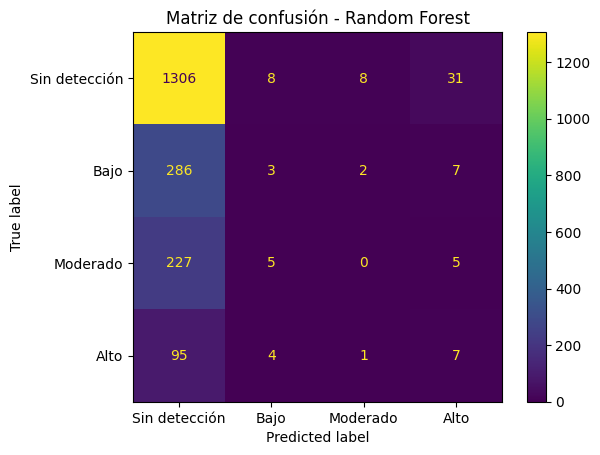

In [31]:
cm = confusion_matrix(
    y_val,
    y_pred_val,
    labels=[
        "Sin detección",
        "Bajo",
        "Moderado",
        "Alto"
    ]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Sin detección",
        "Bajo",
        "Moderado",
        "Alto"
    ]
)

disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

In [ ]:
#La matriz de confusión muestra que el modelo presenta un buen desempeño en la clase Sin detección, 
#con 1306 casos correctamente clasificados. Sin embargo, se observa una alta confusión en las clases Bajo, 
#Moderado y Alto, que son clasificadas mayoritariamente como Sin detección. Esto evidencia un desempeño 
#desigual entre las clases y constituye un aspecto a considerar en las etapas posteriores de experimentación.